# **Day 11 – Data Visualization for Genomics**

**Python for Computational Biology & Bioinformatics**

### Visualizing Gene Expression Patterns in Lung Adenocarcinoma (LUAD)

**Author:** Jagriti Singh

**Course:** Python-for-Computational-Biology

**Repository:** Python-for-Computational-Biology


**Day 11- A**

**Topic**

Data Visualization for Genomics using Matplotlib



###  Goal

Transform cleaned transcriptomic data into meaningful biological visualizations that reveal patterns, trends, and candidate biomarkers.

# **Introduction**

Large-scale genomic and transcriptomic experiments generate thousands of numerical measurements.

Although tables provide detailed information, they rarely reveal overall biological patterns.

Visualization transforms complex numerical data into intuitive graphical representations that allow researchers to rapidly identify:

• Highly expressed genes

• Differential expression patterns

• Outliers

• Distribution of expression values

• Relationships between biological variables

• Potential biomarkers

Visualization is therefore an essential component of computational biology, bioinformatics, and biomedical data science.

# **Why Visualization Matters?**

Modern biological research relies heavily on data visualization.

Researchers use visualizations to:

- Explore RNA-Seq datasets
- Compare gene expression
- Detect experimental errors
- Identify outliers
- Communicate findings
- Generate publication-quality figures

Without visualization, interpreting thousands of gene expression values would be extremely difficult.

Effective visualization enables researchers to transform raw numerical data into biologically meaningful insights.

# **Applications in Computational Biology**

Data visualization is routinely used in:

* Cancer Genomics

* Transcriptomics

* Precision Medicine

* Single-cell RNA-Seq

* Drug Discovery

* Clinical Bioinformatics

* Genome-wide Association Studies (GWAS)

* Machine Learning for Healthcare

# **Learning Objectives**

After completing this notebook, I will be able to:

* Import Matplotlib

* Generate bar charts

* Create line graphs

* Plot histograms

* Construct scatter plots

* Build pie charts

* Create box plots

* Interpret graphical patterns

* Identify highly expressed genes visually

* Detect outliers in transcriptomic datasets

* Prepare publication-quality figures

* Communicate biological findings effectively

In [ ]:
#Google Colab Setup
import pandas as pd
import matplotlib.pyplot as plt

# **Explanation**

Pandas is used to manage tabular biological datasets.

Matplotlib is the standard Python library used to generate scientific figures and publication-quality graphs.

Together, these libraries form the foundation of exploratory data analysis in computational biology.

In [ ]:
import pandas as pd
import numpy as np

np.random.seed(42)

genes = [
    "TP53","BRCA1","EGFR","KRAS","MYC","ALK","BRAF","PIK3CA","CDK4","PTEN",
    "RB1","CCND1","ERBB2","MET","FGFR1","VEGFA","CDH1","SMAD4","APC","NRAS",
    "AKT1","MTOR","NOTCH1","JAK2","STAT3","NFKB1","HIF1A","MDM2","TERT","CDKN2A",
    "ATM","ATR","CHEK1","CHEK2","BCL2","BAX","CASP3","FAS","MMP9","CXCL8",
    "IL6","TGFB1","PDCD1","CD274","CTLA4","LAG3","TIGIT","IFNG","GZMB","PRF1",
    "SOX2","NANOG","POU5F1","VIM","EPCAM","SNAI1","TWIST1","ZEB1","MUC1","KRT18",
    "KRT19","COL1A1","FN1","ITGA6","ITGB1","CXCR4","CCR7","MKI67","PCNA","TOP2A",
    "GATA3","FOXA1","ESR1","AR","RUNX1","IDH1","IDH2","FLT3","KIT","ROS1",
    "RET","NTRK1","NTRK2","NTRK3","SMARCA4","ARID1A","KEAP1","STK11","NF1","NF2",
    "BRIP1","PALB2","RAD51","XRCC1","MSH2","MSH6","MLH1","PMS2","POLE","POLD1"
]

n = len(genes)

df = pd.DataFrame({
    "Gene": genes,
    "Expression": np.round(np.random.uniform(5,25,n),2),
    "Cancer_Type":["LUAD"]*n,
    "Chromosome":np.random.randint(1,23,n),
    "Gene_Type":np.random.choice(
        ["Oncogene","Tumor Suppressor"],n),
    "Log2FC":np.round(np.random.uniform(-4,4,n),2),
    "P_Value":np.round(np.random.uniform(0.0001,0.05,n),4),
    "Adjusted_P_Value":np.round(np.random.uniform(0.0001,0.05,n),4)
})

df["Status"]=np.where(
    df["Log2FC"]>0,
    "Upregulated",
    "Downregulated"
)

df.to_csv("LUAD_Gene_Expression_Dataset.csv",index=False)

print("Dataset created successfully!")

Dataset created successfully!


In [ ]:
#Load the Clean Dataset
df = pd.read_csv("LUAD_Gene_Expression_Dataset.csv")

df.head()

,Gene,Expression,Cancer_Type,Chromosome,Gene_Type,Log2FC,P_Value,Adjusted_P_Value,Status
0,TP53,12.49,LUAD,7,Oncogene,0.62,0.0008,0.0309,Upregulated
1,BRCA1,24.01,LUAD,17,Oncogene,-0.06,0.0059,0.0051,Downregulated
2,EGFR,19.64,LUAD,20,Tumor Suppressor,-2.44,0.0024,0.0043,Downregulated
3,KRAS,16.97,LUAD,4,Tumor Suppressor,1.78,0.0021,0.0351,Upregulated
4,MYC,8.12,LUAD,5,Oncogene,-1.75,0.0428,0.0037,Downregulated


# **Explanation**
The LUAD dataset created in Day 10 has been loaded successfully.

Rather than generating a new dataset, we continue working with the same transcriptomic data.

This reflects real computational biology projects, where cleaned datasets are reused for multiple downstream analyses such as visualization, statistical testing, and machine learning.


In [ ]:
print(df.shape)

print(df.columns)

df.info()

(100, 9)
Index(['Gene', 'Expression', 'Cancer_Type', 'Chromosome', 'Gene_Type',
       'Log2FC', 'P_Value', 'Adjusted_P_Value', 'Status'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Gene              100 non-null    object 
 1   Expression        100 non-null    float64
 2   Cancer_Type       100 non-null    object 
 3   Chromosome        100 non-null    int64  
 4   Gene_Type         100 non-null    object 
 5   Log2FC            100 non-null    float64
 6   P_Value           100 non-null    float64
 7   Adjusted_P_Value  100 non-null    float64
 8   Status            100 non-null    object 
dtypes: float64(4), int64(1), object(4)
memory usage: 7.2+ KB


Although the dataset was already explored in Day 10, researchers routinely verify datasets before beginning a new stage of analysis.

This ensures that:

- The correct dataset has been loaded.
- Column names are accurate.
- Data types are appropriate.
- No information was lost during previous processing steps.

# **Research Note**

Data visualization is typically performed after:

* Data cleaning

* Quality control

* Missing value handling

* Exploratory statistical analysis

This sequence ensures that graphical representations accurately reflect the underlying biological data.

Visualizing uncleaned datasets may lead to misleading conclusions.

# **Part 11-A Summary**

In this introductory section, I explored the importance of data visualization in computational biology and genomics. I learned how graphical representations transform complex gene expression datasets into intuitive visual patterns that support biological interpretation and scientific communication. Using Matplotlib, I prepared the computational environment for visualization and reloaded the cleaned LUAD gene expression dataset generated in Day 10.

I also reviewed the role of visualization within a standard transcriptomic analysis workflow, emphasizing that high-quality figures should always be created after data cleaning, quality assessment, and exploratory statistical analysis. This section established the foundation for producing publication-quality visualizations that will be used throughout the remaining notebooks in this computational biology portfolio.

# **Key Takeaways**

- Introduced Matplotlib for genomic data visualization.
- Loaded the cleaned LUAD gene expression dataset.
- Reviewed why visualization is essential in computational biology.
- Established a research-oriented workflow for graphical analysis.
- Prepared the dataset for creating publication-quality figures.

# **Part 11-B- Visualizing Gene Expression Using Bar Charts**
After completing exploratory statistical analysis, researchers often visualize gene expression levels to identify biologically important genes.

A bar chart is one of the simplest and most effective ways to compare expression levels among genes.

Instead of reading hundreds of numerical values from a table, visualization allows researchers to quickly recognize:

- Highly expressed genes
- Weakly expressed genes
- Relative differences between genes
- Candidate biomarkers
- Potential therapeutic targets

In this section, we will generate publication-style bar charts using our LUAD gene expression dataset and interpret the biological significance of the observed patterns.

# **Biological Importance**

**Why Bar Charts Matter in Transcriptomics?**

Bar charts are frequently used during exploratory analysis of RNA-Seq and microarray datasets.

Researchers use them to:

- Compare expression levels across genes.
- Highlight highly expressed biomarkers.
- Compare treated vs untreated samples.
- Present publication-quality figures.
- Summarize differential expression results.

Although advanced visualizations such as heatmaps and volcano plots are widely used, bar charts remain an essential first s

# **Research Objective**

Our objective is to identify the most highly expressed genes in the LUAD dataset.

Instead of examining all 100 genes simultaneously, we will first rank them according to expression level and visualize the top 10 genes.

This approach simplifies interpretation and mirrors common practices in transcriptomic research.

In [ ]:
# Sort genes according to expression level

expression_sorted = df.sort_values(
    by="Expression",
    ascending=False
)

expression_sorted.head(10)

,Gene,Expression,Cancer_Type,Chromosome,Gene_Type,Log2FC,P_Value,Adjusted_P_Value,Status
69,TOP2A,24.74,LUAD,6,Tumor Suppressor,0.25,0.0451,0.0269,Upregulated
11,CCND1,24.40,LUAD,7,Tumor Suppressor,-1.04,0.0217,0.0186,Downregulated
50,SOX2,24.39,LUAD,17,Oncogene,-1.00,0.0315,0.0228,Downregulated
34,BCL2,24.31,LUAD,5,Tumor Suppressor,1.58,0.0481,0.0144,Upregulated
1,BRCA1,24.01,LUAD,17,Oncogene,-0.06,0.0059,0.0051,Downregulated
33,CHEK2,23.98,LUAD,9,Tumor Suppressor,1.93,0.0194,0.0188,Upregulated
52,POU5F1,23.79,LUAD,17,Oncogene,0.63,0.0368,0.0293,Upregulated
55,SNAI1,23.44,LUAD,2,Tumor Suppressor,0.34,0.0090,0.0141,Upregulated
43,CD274,23.19,LUAD,17,Tumor Suppressor,0.01,0.0160,0.0496,Upregulated
53,VIM,22.90,LUAD,17,Tumor Suppressor,-3.71,0.0402,0.0451,Downregulated


# **Explanation**

Before creating a graph, we first rank genes according to their expression levels.

The highest expressed genes appear at the top of the table.

These genes are the primary candidates for visualization because they may represent biologically active genes involved in tumor development or progression.

In [ ]:
top10 = expression_sorted.head(10)

top10

,Gene,Expression,Cancer_Type,Chromosome,Gene_Type,Log2FC,P_Value,Adjusted_P_Value,Status
69,TOP2A,24.74,LUAD,6,Tumor Suppressor,0.25,0.0451,0.0269,Upregulated
11,CCND1,24.40,LUAD,7,Tumor Suppressor,-1.04,0.0217,0.0186,Downregulated
50,SOX2,24.39,LUAD,17,Oncogene,-1.00,0.0315,0.0228,Downregulated
34,BCL2,24.31,LUAD,5,Tumor Suppressor,1.58,0.0481,0.0144,Upregulated
1,BRCA1,24.01,LUAD,17,Oncogene,-0.06,0.0059,0.0051,Downregulated
33,CHEK2,23.98,LUAD,9,Tumor Suppressor,1.93,0.0194,0.0188,Upregulated
52,POU5F1,23.79,LUAD,17,Oncogene,0.63,0.0368,0.0293,Upregulated
55,SNAI1,23.44,LUAD,2,Tumor Suppressor,0.34,0.0090,0.0141,Upregulated
43,CD274,23.19,LUAD,17,Tumor Suppressor,0.01,0.0160,0.0496,Upregulated
53,VIM,22.90,LUAD,17,Tumor Suppressor,-3.71,0.0402,0.0451,Downregulated


# **Why Focus on the Top 10 Genes?**

Large transcriptomic datasets may contain tens of thousands of genes.

Plotting all genes simultaneously would produce a cluttered and difficult-to-interpret figure.

Selecting the top 10 highly expressed genes allows us to focus on the most biologically relevant candidates while producing a clear and informative visualization.

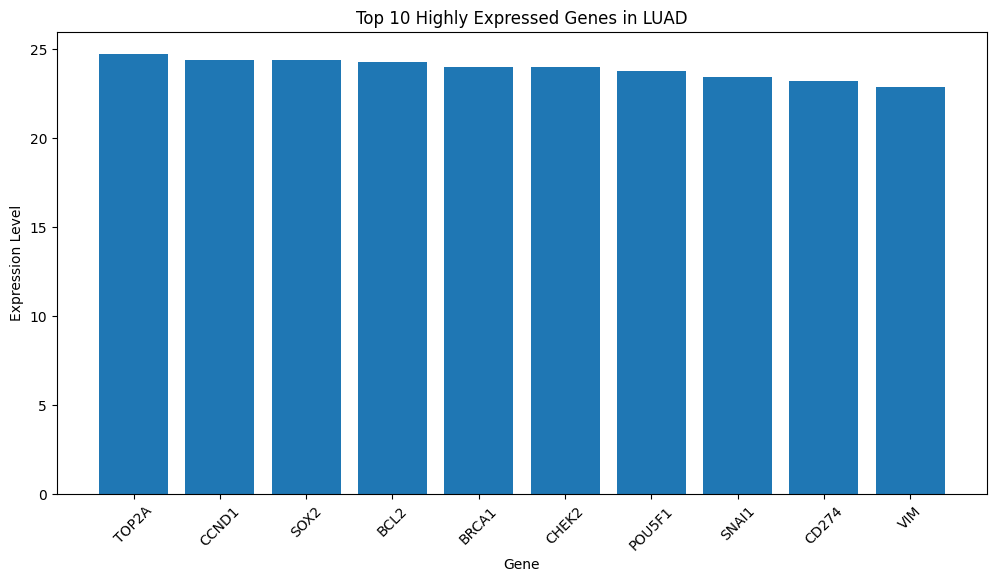

In [ ]:
plt.figure(figsize=(12,6))

plt.bar(
    top10["Gene"],
    top10["Expression"]
)

plt.title("Top 10 Highly Expressed Genes in LUAD")

plt.xlabel("Gene")

plt.ylabel("Expression Level")

plt.xticks(rotation=45)

plt.show()

# **Understanding the Figure**

* The x-axis displays the gene symbols.

* The y-axis represents normalized gene expression levels.

* Taller bars indicate genes with higher expression.

* Shorter bars indicate genes with lower expression among the selected top genes.

This visualization immediately highlights the most transcriptionally active genes in the dataset.

# **Biological Interpretation**

Genes exhibiting the highest expression levels are often prioritized for further investigation because they may:

- Act as oncogenes.
- Participate in important signaling pathways.
- Influence tumor progression.
- Serve as diagnostic biomarkers.
- Become therapeutic targets.

For example,

if genes such as **EGFR**, **MYC**, or **ALK** appear among the most highly expressed genes, they may warrant additional functional and clinical investigation.

# **Research Note**

In RNA-Seq studies, expression values are often normalized before visualization.

Normalization ensures that differences in sequencing depth or library size do not bias comparisons between genes or samples.

The normalized values visualized in this notebook simulate those commonly reported in transcriptomic studies.

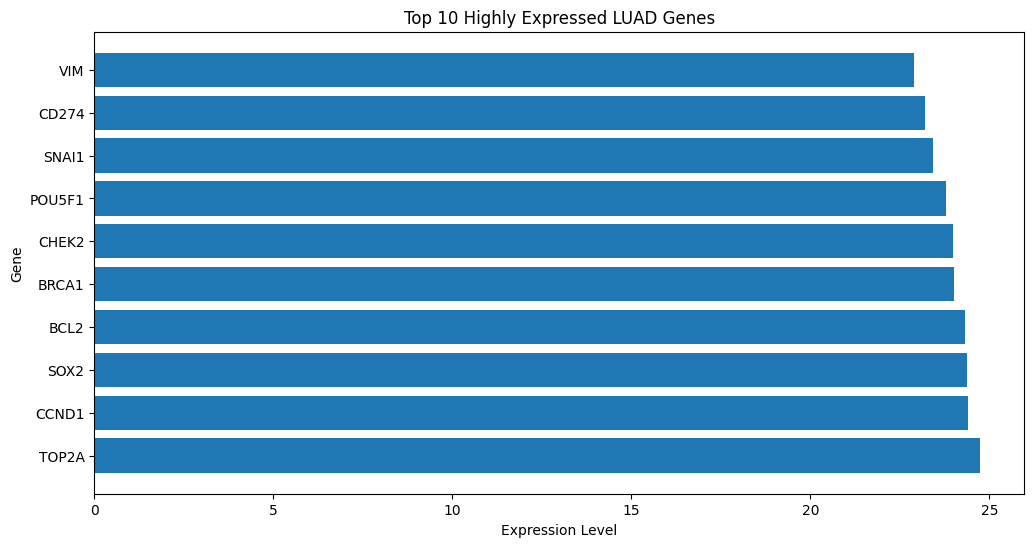

In [ ]:
#Horizontal Bar Chart
plt.figure(figsize=(12,6))

plt.barh(
    top10["Gene"],
    top10["Expression"]
)

plt.title("Top 10 Highly Expressed LUAD Genes")

plt.xlabel("Expression Level")

plt.ylabel("Gene")

plt.show()

# **Why Use a Horizontal Bar Chart?**

Horizontal bar charts improve readability when gene names are long or numerous.

They are commonly used in scientific publications because labels remain easy to read and figures fit well within manuscripts and presentations.

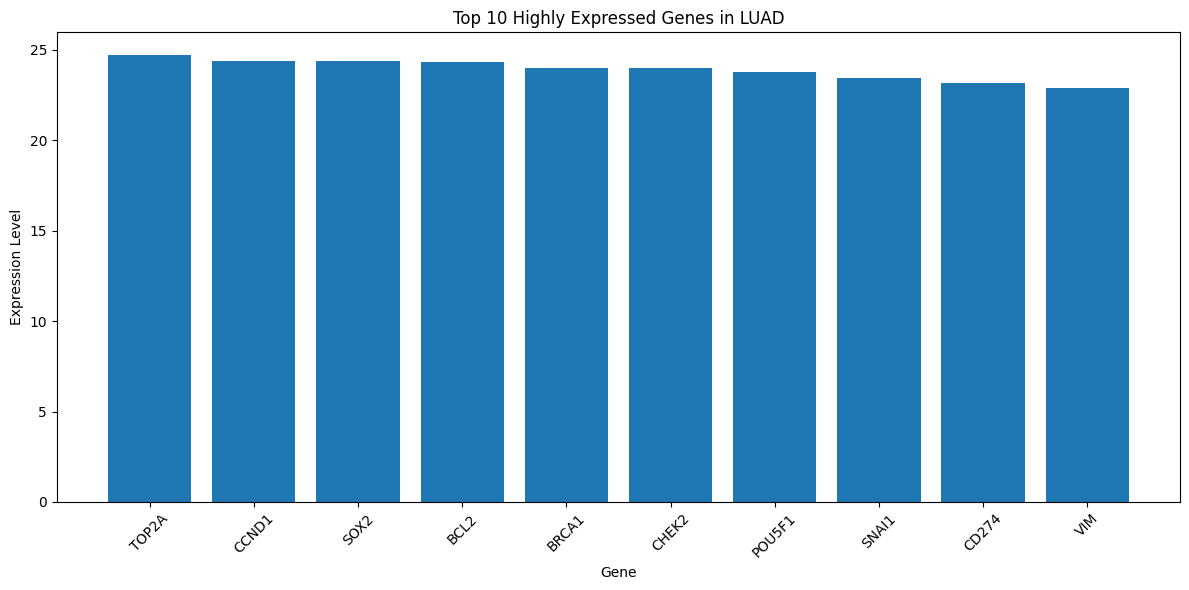

Figure saved successfully!


In [ ]:
plt.figure(figsize=(12,6))

plt.bar(
    top10["Gene"],
    top10["Expression"]
)

plt.title("Top 10 Highly Expressed Genes in LUAD")

plt.xlabel("Gene")

plt.ylabel("Expression Level")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "Top10_LUAD_Gene_Expression.png",
    dpi=300
)

plt.show()

print("Figure saved successfully!")

# **Saving Publication-Quality Figures**

The `savefig()` function exports graphs as image files.

Researchers frequently save figures for:

- Research manuscripts
- Conference presentations
- Laboratory reports
- Thesis chapters
- Scientific posters

A resolution of **300 DPI** is widely accepted for publication-quality graphics.

# **Mini Research Exercise**

A cancer genomics laboratory wants to identify the most highly expressed genes in a LUAD RNA-Seq dataset.

Tasks:

1. Sort the genes by expression level.

2. Select the top 10 genes.

3. Create a vertical bar chart.

4. Create a horizontal bar chart.

5. Save the graph as a PNG image.

6. Write a biological interpretation describing why the highly expressed genes may be important in cancer research.

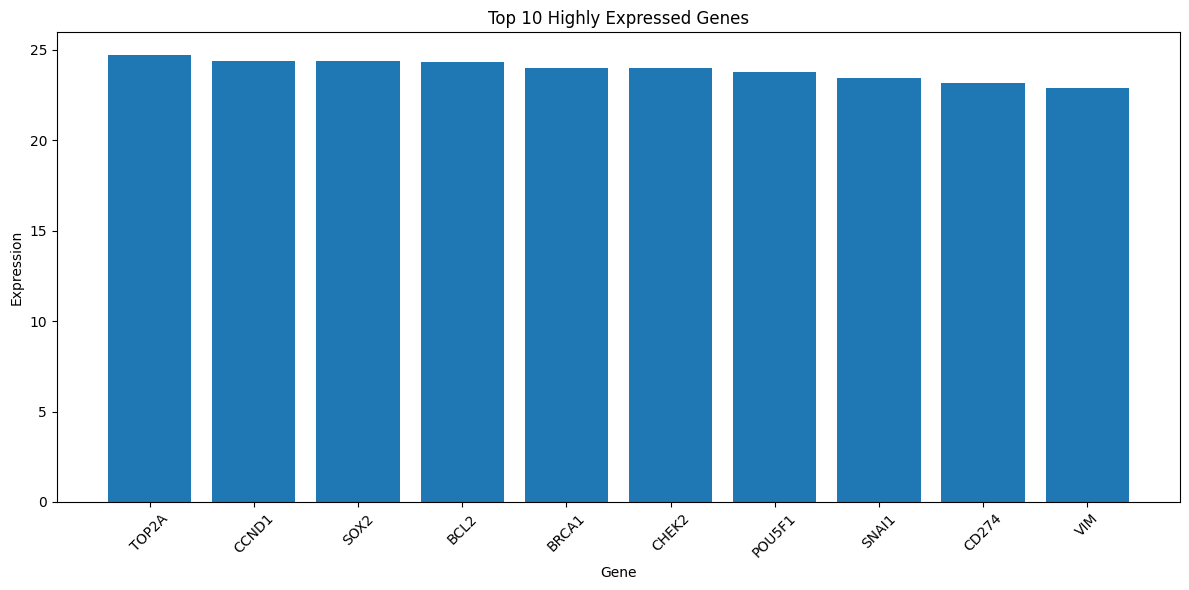

In [ ]:
expression_sorted = df.sort_values(
    by="Expression",
    ascending=False
)

top10 = expression_sorted.head(10)

plt.figure(figsize=(12,6))

plt.bar(
    top10["Gene"],
    top10["Expression"]
)

plt.title("Top 10 Highly Expressed Genes")

plt.xlabel("Gene")

plt.ylabel("Expression")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

# **Research Reflection**

Visualizing gene expression levels using bar charts provided an intuitive understanding of transcriptional activity within the LUAD dataset. Instead of interpreting numerical values alone, graphical representation made it easier to identify highly expressed genes that could represent potential biomarkers or therapeutic targets. This approach complements exploratory statistical analysis and illustrates how visualization supports biological interpretation in transcriptomic research.

# **Publication Insight**

Figures similar to those created in this section are commonly included in scientific publications investigating:

- Lung Adenocarcinoma
- Breast Cancer
- Glioblastoma
- Colorectal Cancer
- Differential Gene Expression Studies

Bar charts are often used to summarize the expression levels of selected biomarkers before more advanced visualizations such as heatmaps, volcano plots, or pathway diagrams.

## **Part 11-B Summary**

In this section, I visualized the expression levels of the top-ranked genes in a simulated LUAD RNA-Seq dataset using Matplotlib. By transforming numerical expression values into bar charts, I identified highly expressed genes and explored their potential biological significance. This visualization represents one of the first graphical analyses routinely performed in transcriptomic studies and provides a foundation for more advanced genomic visualizations.

# **Key Takeaways**

* Learned how to rank genes by expression level.

* Selected biologically important genes for visualization.

* Created vertical and horizontal bar charts.

* Saved publication-quality figures.

* Interpreted graphical representations of transcriptomic data.

* Connected visualization with biological significance and biomarker discovery.

# **Part 11-C -Understanding Gene Expression Distribution Using Histograms**


In the previous section, we visualized the expression levels of individual genes using bar charts.

Although bar charts are useful for comparing selected genes, they do not provide an overview of the entire dataset.

To understand how expression values are distributed across all genes, researchers commonly use **histograms**.

A histogram groups numerical values into intervals (called bins) and displays how many observations fall within each interval.

Instead of focusing on individual genes, histograms help answer broader biological questions such as:

- Are most genes expressed at low, moderate, or high levels?
- Is the expression distribution symmetrical or skewed?
- Are there unusually highly expressed genes?
- Does the dataset contain potential outliers?

Understanding the overall distribution of expression values is an essential step before downstream statistical analyses and visualization.

# **Biological Importance**

 **Why Histograms Matter in Computational Biology**

Histograms are routinely used in transcriptomic research to evaluate the distribution of gene expression values.

Researchers use histograms to:

- Assess data quality.
- Identify skewed distributions.
- Detect highly expressed genes.
- Identify possible outliers.
- Evaluate whether normalization has been successful.
- Decide which statistical methods are appropriate for downstream analysis.

A histogram provides a quick visual summary of the molecular characteristics of an RNA-Seq dataset.

# **Research Objective**

In this section, we will visualize the distribution of normalized gene expression values across the LUAD dataset.

Our objectives are to:

* Examine the overall distribution of expression values.

* Identify regions containing the highest number of genes.

* Detect unusually high or low expression values.

* Interpret biological patterns observed in the transcriptomic dataset.

In [ ]:
df["Expression"].head(10)

,Expression
0,12.49
1,24.01
2,19.64
3,16.97
4,8.12
5,8.12
6,6.16
7,22.32
8,17.02
9,19.16


# **Explanation**

Before constructing a histogram, we inspect several expression values.

Each value represents the normalized expression level of a gene.

Rather than examining these numbers individually, a histogram summarizes their overall distribution.

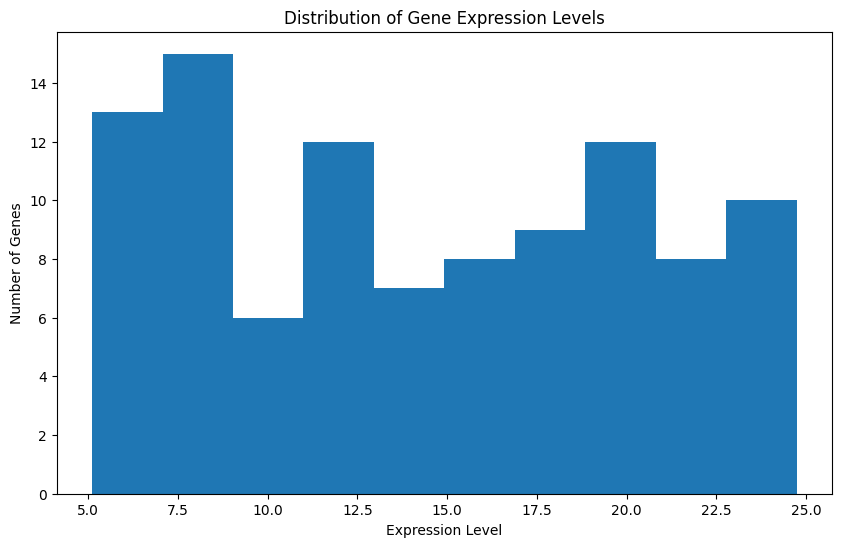

In [ ]:
plt.figure(figsize=(10,6))

plt.hist(
    df["Expression"],
    bins=10
)

plt.title("Distribution of Gene Expression Levels")

plt.xlabel("Expression Level")

plt.ylabel("Number of Genes")

plt.show()

# **Understanding the Histogram**

Unlike a bar chart, each bar in a histogram represents a **range of expression values**, not an individual gene.

For example:

Expression Range

5–7

↓

Number of Genes within that interval

The height of each bar indicates how many genes fall within a particular expression range.

This provides an overview of the expression profile of the entire transcriptomic dataset.

# **Biological Interpretation**

The histogram reveals how expression values are distributed across all genes.

Possible observations include:

- Most genes exhibit moderate expression.
- A few genes display exceptionally high expression.
- Some genes show very low expression.

Highly expressed genes often represent biologically active genes involved in cellular signaling, proliferation, or cancer progression.

Conversely, genes with low expression may be tissue-specific, inactive, or weakly transcribed.

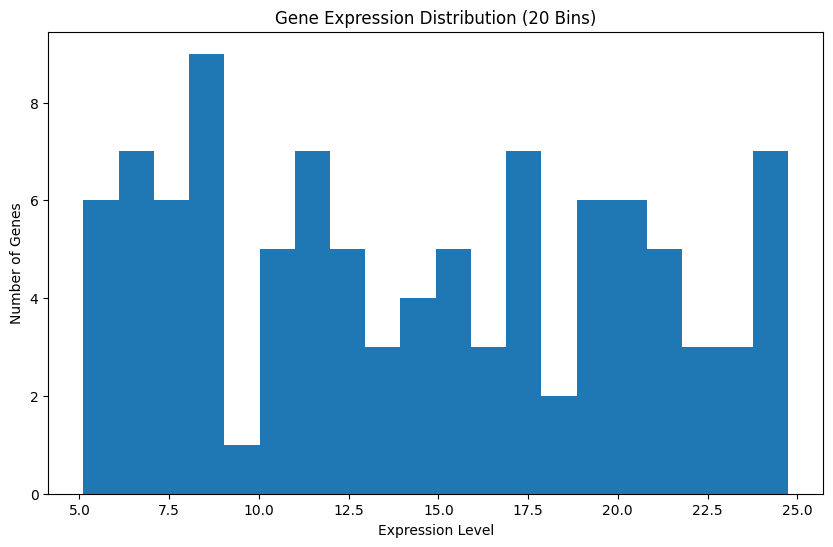

In [ ]:
#Increase Number of Bins
plt.figure(figsize=(10,6))

plt.hist(
    df["Expression"],
    bins=20
)

plt.title("Gene Expression Distribution (20 Bins)")

plt.xlabel("Expression Level")

plt.ylabel("Number of Genes")

plt.show()

# **Why Change the Number of Bins?**

The **bins** parameter controls how expression values are grouped.

Fewer bins produce a simpler overview.

More bins reveal finer details within the distribution.

Researchers often experiment with different bin sizes before selecting the most informative visualization.

In [ ]:
#Mean Expression
print("Average Expression:")

print(df["Expression"].mean())

Average Expression:
14.403200000000002


In [ ]:
#Median Expression
print("Median Expression:")

print(df["Expression"].median())

Median Expression:
14.28


# **Connecting Statistics and Visualization**

Histograms become much more informative when interpreted together with descriptive statistics.

The **mean** and **median** help describe the center of the distribution.

Comparing these values provides insight into whether the distribution is approximately symmetrical or skewed.

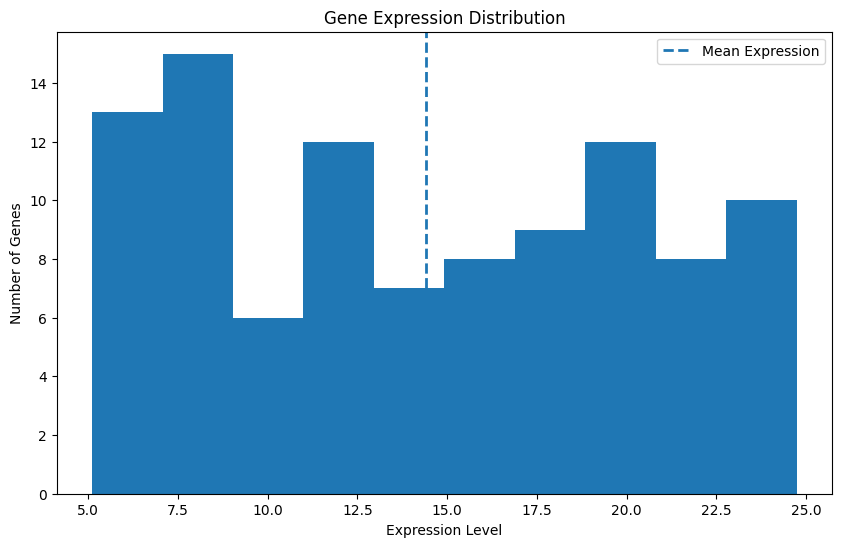

In [ ]:
#Mean Line on Histogram
plt.figure(figsize=(10,6))

plt.hist(
    df["Expression"],
    bins=10
)

plt.axvline(
    df["Expression"].mean(),
    linestyle="--",
    linewidth=2,
    label="Mean Expression"
)

plt.title("Gene Expression Distribution")

plt.xlabel("Expression Level")

plt.ylabel("Number of Genes")

plt.legend()

plt.show()

# **Understanding the Mean Line**

The dashed vertical line represents the average expression level.

Genes located far to the right of this line have expression values above the dataset average.

These genes may represent biologically important candidates for further investigation.

# **Research Note**

Histograms are routinely generated immediately after importing RNA-Seq datasets.

Researchers examine these plots to:

- Verify successful normalization.
- Detect abnormal distributions.
- Identify potential outliers.
- Evaluate overall data quality.

Only after confirming that the data appear biologically reasonable do researchers proceed to downstream analyses such as clustering, pathway enrichment, or machine learning.

# **Mini Research Exercise**

A computational biology laboratory has received an RNA-Seq dataset from lung adenocarcinoma patients.

Your tasks are:

1. Create a histogram of expression values.

2. Generate another histogram using 20 bins.

3. Calculate the mean expression level.

4. Calculate the median expression level.

5. Compare the histogram with the calculated statistics.

6. Write a biological interpretation describing the overall expression distribution and discuss whether highly expressed genes may represent candidate biomarkers.

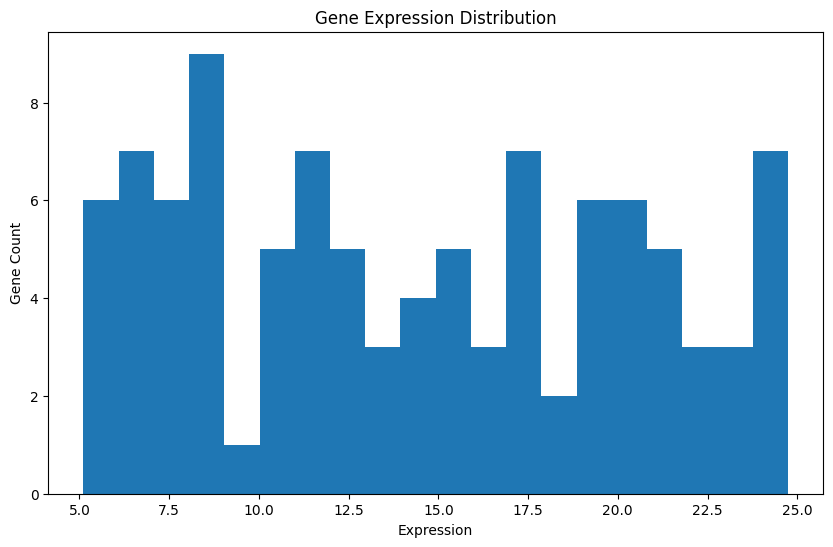

Mean: 14.403200000000002
Median: 14.28


In [ ]:
plt.figure(figsize=(10,6))

plt.hist(df["Expression"], bins=20)

plt.title("Gene Expression Distribution")

plt.xlabel("Expression")

plt.ylabel("Gene Count")

plt.show()

print("Mean:", df["Expression"].mean())

print("Median:", df["Expression"].median())

# **Research Reflection**

Constructing histograms allowed me to move beyond examining individual genes and instead understand the overall transcriptomic landscape of the LUAD dataset. By combining visualization with descriptive statistics, I gained a clearer understanding of how expression values are distributed across genes and how unusually high-expression genes may represent biologically important candidates. This type of exploratory visualization is a fundamental component of RNA-Seq quality assessment and supports more informed downstream analyses.

# **Part 11-C Summary**

In this section, I explored the distribution of gene expression values using histograms. Unlike bar charts that compare individual genes, histograms summarize the overall characteristics of the transcriptomic dataset. By visualizing expression distributions and relating them to descriptive statistics such as the mean and median, I developed a deeper understanding of data quality, biological variability, and the identification of potentially important genes. These exploratory analyses are routinely performed before advanced transcriptomic methods such as clustering, differential expression analysis, and machine learning.

#  Key Takeaways

* Learned how to construct histograms using Matplotlib.

*  Understood the difference between bar charts and histograms.

* Examined the overall distribution of gene expression values.

* Connected descriptive statistics with graphical interpretation.

* Identified potential high-expression genes for further investigation.

* Appreciated the role of histograms in RNA-Seq quality assessment.

# **Part 11-D Exploring Relationships Between Biological Variables Using Scatter Plots**
In the previous section, we examined the distribution of gene expression values using histograms. Histograms summarize a single numerical variable.

However, biological research often requires understanding how **two variables relate to each other**.

Scatter plots are among the most widely used visualizations in transcriptomics because they reveal relationships, trends, clusters, and potential outliers.

In this section, we will investigate the relationship between:

- Gene Expression and Log₂ Fold Change
- Gene Expression and Adjusted P-value

These analyses help researchers prioritize genes that may serve as candidate biomarkers or therapeutic targets.

# **Biological Importance**

**Why Scatter Plots Matter in Transcriptomics?**

Scatter plots are fundamental tools in computational biology because they allow researchers to compare two continuous variables simultaneously.

In RNA-Seq studies, scatter plots are commonly used to:

- Compare expression between experimental groups.
- Visualize differential gene expression.
- Detect highly expressed biomarkers.
- Identify potential outliers.
- Explore correlations between biological variables.
- Support downstream analyses such as volcano plots and clustering.

Unlike histograms, scatter plots help answer whether one biological measurement changes as another changes.

# **Learning Objectives**

After completing this section, I will be able to:

*  Create scatter plots using Matplotlib.

* Compare gene expression with Log₂ Fold Change.

* Compare gene expression with Adjusted P-values.

* Identify genes with high biological importance.

* Detect trends and possible correlations.

* Interpret scatter plots in the context of transcriptomic research.

# **Research Workflow**

The following workflow represents a common exploratory analysis performed after differential expression analysis.

```
  LUAD Gene Expression Dataset
            │
            ▼
     Expression Values
            │
            ▼
     Compare With Log₂ Fold Change
            │
            ▼
    Compare With Adjusted P-value
            │
            ▼
    Identify Candidate Biomarkers
            │
            ▼
     Biological Interpretation
            │
            ▼
      Functional Validation
```

# **Section 11-D.1**

In [ ]:
# Display selected biological variables

df[[
    "Gene",
    "Expression",
    "Log2FC",
    "Adjusted_P_Value"
]].head(10)

,Gene,Expression,Log2FC,Adjusted_P_Value
0,TP53,12.49,0.62,0.0309
1,BRCA1,24.01,-0.06,0.0051
2,EGFR,19.64,-2.44,0.0043
3,KRAS,16.97,1.78,0.0351
4,MYC,8.12,-1.75,0.0037
5,ALK,8.12,-3.81,0.0411
6,BRAF,6.16,1.16,0.0353
7,PIK3CA,22.32,-2.58,0.0042
8,CDK4,17.02,3.52,0.0043
9,PTEN,19.16,3.63,0.0493


# **Understanding the Variables**

This table displays the variables that will be compared throughout this section.

Expression

Represents the normalized expression level of each gene.

Log₂ Fold Change

Measures how much gene expression changes between two biological conditions.

Adjusted P-value

Represents the statistical significance of the observed expression difference after correcting for multiple hypothesis testing.

Together, these variables summarize both the biological magnitude and statistical confidence of differential gene expression.

# **Section 11-D.2 - Scatter Plot**
**Expression vs Log₂ Fold Change**

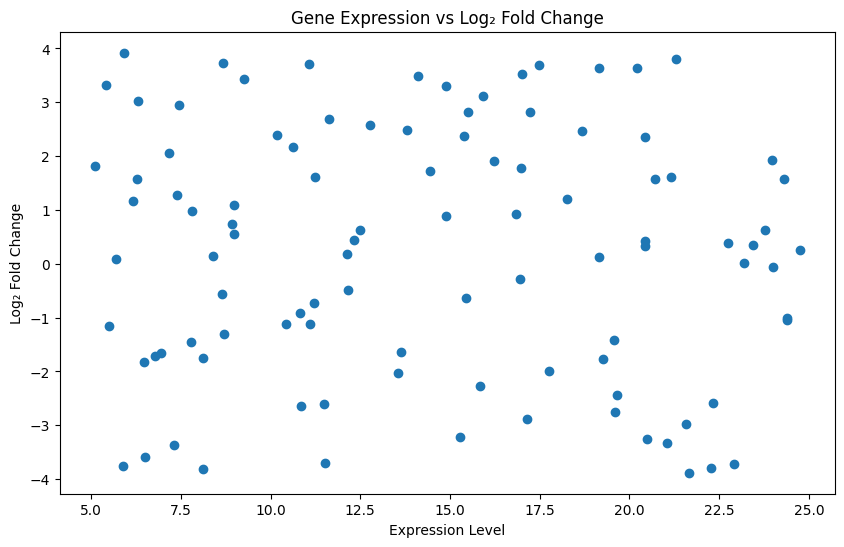

In [ ]:
plt.figure(figsize=(10,6))

plt.scatter(
    df["Expression"],
    df["Log2FC"]
)

plt.title("Gene Expression vs Log₂ Fold Change")

plt.xlabel("Expression Level")

plt.ylabel("Log₂ Fold Change")

plt.show()

# **Understanding the Scatter Plot**

Each point represents one gene.

X-axis

Gene expression level.

Y-axis

Log₂ Fold Change.

Genes positioned higher on the graph have larger positive fold changes.

Genes positioned lower have negative fold changes.

Scatter plots reveal whether genes with higher expression also tend to show larger expression changes.

# **Biological Interpretation**

Genes located in the upper-right region of the plot typically have:

- High expression
- Positive Log₂ Fold Change

These genes are frequently investigated because they may represent activated oncogenes or disease-associated biomarkers.

Genes in the lower-right region exhibit high expression but negative fold changes, suggesting decreased activity under the studied condition.

Scatter plots help researchers prioritize biologically relevant genes before performing pathway enrichment or functional validation.

# **Section 11-D.3 -Add Grid**

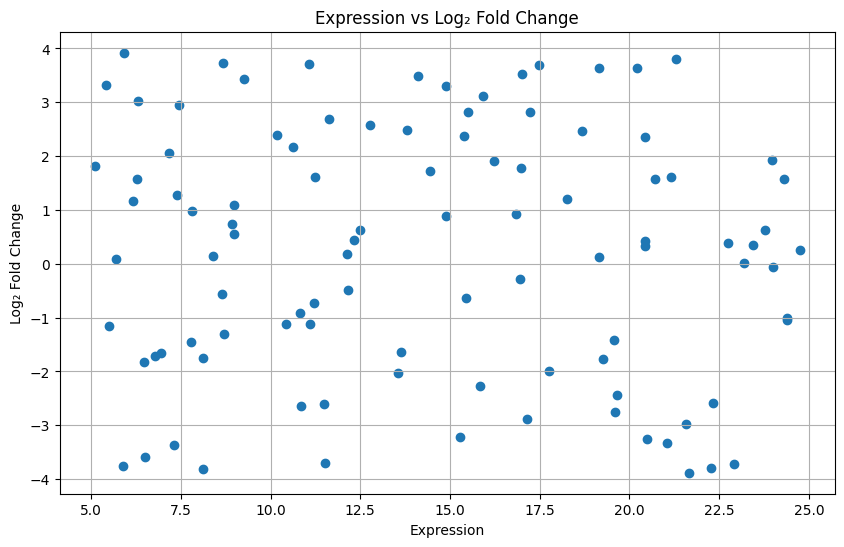

In [ ]:
plt.figure(figsize=(10,6))

plt.scatter(
    df["Expression"],
    df["Log2FC"]
)

plt.grid(True)

plt.title("Expression vs Log₂ Fold Change")

plt.xlabel("Expression")

plt.ylabel("Log₂ Fold Change")

plt.show()

# **Why Add a Grid?**

Grids improve readability by making it easier to estimate the coordinates of individual genes.

Publication-quality scientific figures frequently include grids to assist interpretation without distracting from the data.

# **Section 11-D.4- Expression vs Adjusted P-value**

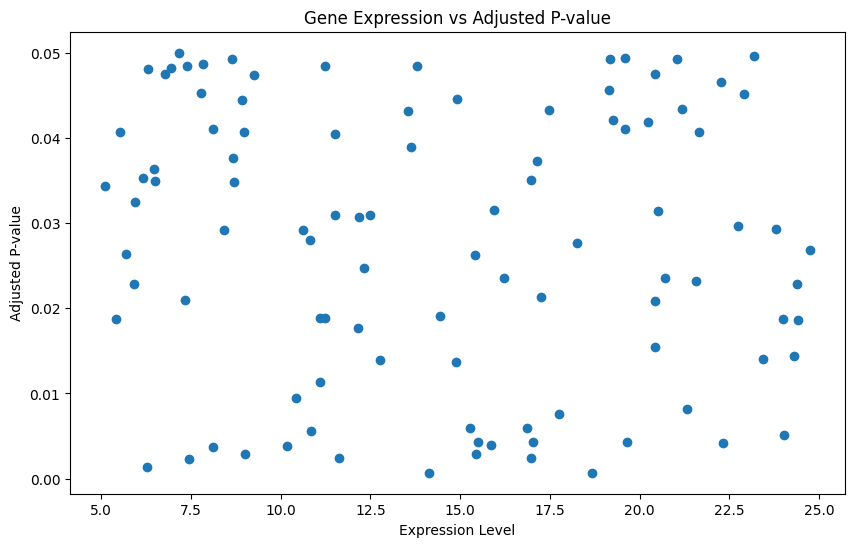

In [ ]:
plt.figure(figsize=(10,6))

plt.scatter(
    df["Expression"],
    df["Adjusted_P_Value"]
)

plt.title("Gene Expression vs Adjusted P-value")

plt.xlabel("Expression Level")

plt.ylabel("Adjusted P-value")

plt.show()

# **Understanding the Figure**

Each point represents one gene.

Genes with:

• High expression

and

• Low adjusted P-values

are generally considered more biologically reliable.

These genes often receive higher priority for downstream experimental validation.

# **Biological Interpretation**

Genes appearing toward the lower-right region of the scatter plot combine:

* High expression

* Strong statistical significance

These characteristics make them attractive candidates for:

- Biomarker discovery
- Drug target identification
- Functional validation
- Precision medicine studies

# **Section 11-D.5 - Candidate Biomarker Identification**


In [ ]:
candidate = df[
    (df["Expression"] > 18) &
    (df["Adjusted_P_Value"] < 0.05)
]

candidate

,Gene,Expression,Cancer_Type,Chromosome,Gene_Type,Log2FC,P_Value,Adjusted_P_Value,Status
1,BRCA1,24.01,LUAD,17,Oncogene,-0.06,0.0059,0.0051,Downregulated
2,EGFR,19.64,LUAD,20,Tumor Suppressor,-2.44,0.0024,0.0043,Downregulated
7,PIK3CA,22.32,LUAD,15,Tumor Suppressor,-2.58,0.0050,0.0042,Downregulated
9,PTEN,19.16,LUAD,4,Tumor Suppressor,3.63,0.0237,0.0493,Upregulated
11,CCND1,24.40,LUAD,7,Tumor Suppressor,-1.04,0.0217,0.0186,Downregulated
12,ERBB2,21.65,LUAD,19,Tumor Suppressor,-3.88,0.0200,0.0407,Downregulated
25,NFKB1,20.70,LUAD,1,Oncogene,1.57,0.0293,0.0235,Upregulated
33,CHEK2,23.98,LUAD,9,Tumor Suppressor,1.93,0.0194,0.0188,Upregulated
34,BCL2,24.31,LUAD,5,Tumor Suppressor,1.58,0.0481,0.0144,Upregulated
35,BAX,21.17,LUAD,1,Oncogene,1.62,0.0453,0.0434,Upregulated


# **Interpretation**

This filtering strategy combines biological magnitude (high expression) with statistical confidence (low adjusted P-value).

Researchers often apply similar criteria to reduce thousands of genes to a manageable list of candidate biomarkers for further experimental validation.

# **Section 11-D.6 -Count Candidate Biomarkers**

In [ ]:
print("Candidate Biomarkers:")

print(len(candidate))

Candidate Biomarkers:
32


# **Research Note**

Real RNA-Seq studies commonly use scatter plots during exploratory analysis before constructing volcano plots or performing pathway enrichment analysis.

Although scatter plots are simple, they provide valuable insight into:

- expression trends
- variability
- statistically significant genes
- potential outliers

These visualizations guide downstream analyses and help researchers formulate biological hypotheses.

# **Publication Insight**

Scatter plots similar to those created in this notebook appear frequently in studies involving:

- Lung Adenocarcinoma
- Breast Cancer
- Glioblastoma
- Colorectal Cancer
- Single-cell RNA-Seq
- Differential Gene Expression Analysis

They serve as preliminary visualizations before more specialized figures such as volcano plots, MA plots, or heatmaps.

# **Mini Research Exercise**

A cancer genomics laboratory has completed differential gene expression analysis for LUAD samples.

Your tasks are:

1. Create a scatter plot of Expression vs Log₂ Fold Change.

2. Create another scatter plot of Expression vs Adjusted P-value.

3. Identify genes with:

- Expression > 18

- Adjusted P-value < 0.05

4. Count the number of candidate biomarkers.

5. Write a biological interpretation describing how scatter plots assist in identifying biologically relevant genes.

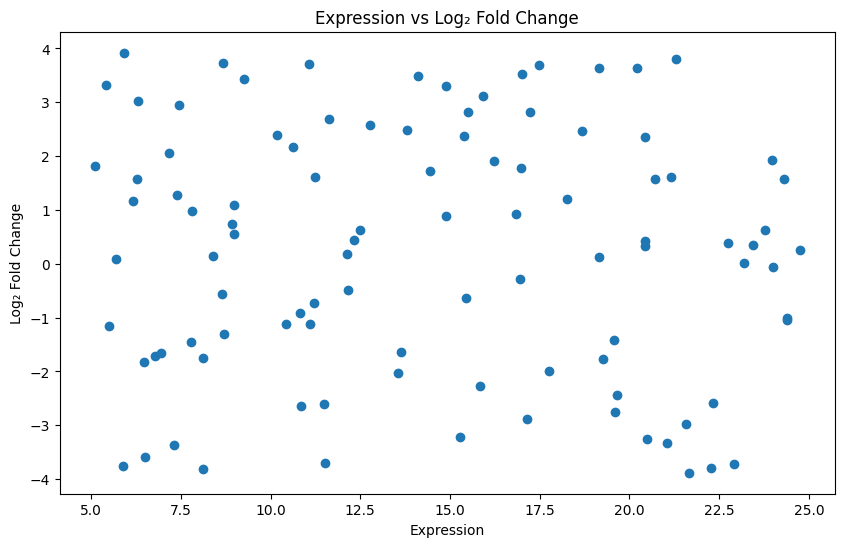

      Gene  Expression Cancer_Type  Chromosome         Gene_Type  Log2FC  \
1    BRCA1       24.01        LUAD          17          Oncogene   -0.06   
2     EGFR       19.64        LUAD          20  Tumor Suppressor   -2.44   
7   PIK3CA       22.32        LUAD          15  Tumor Suppressor   -2.58   
9     PTEN       19.16        LUAD           4  Tumor Suppressor    3.63   
11   CCND1       24.40        LUAD           7  Tumor Suppressor   -1.04   
12   ERBB2       21.65        LUAD          19  Tumor Suppressor   -3.88   
25   NFKB1       20.70        LUAD           1          Oncogene    1.57   
33   CHEK2       23.98        LUAD           9  Tumor Suppressor    1.93   
34    BCL2       24.31        LUAD           5  Tumor Suppressor    1.58   
35     BAX       21.17        LUAD           1          Oncogene    1.62   
38    MMP9       18.68        LUAD          12          Oncogene    2.47   
43   CD274       23.19        LUAD          17  Tumor Suppressor    0.01   
45    LAG3  

In [ ]:
candidate = df[
    (df["Expression"] > 18) &
    (df["Adjusted_P_Value"] < 0.05)
]

plt.figure(figsize=(10,6))

plt.scatter(
    df["Expression"],
    df["Log2FC"]
)

plt.xlabel("Expression")

plt.ylabel("Log₂ Fold Change")

plt.title("Expression vs Log₂ Fold Change")

plt.show()

print(candidate)

# **Research Reflection**

Scatter plots provided a more comprehensive understanding of the LUAD dataset by allowing simultaneous visualization of two biological variables. Unlike bar charts or histograms, scatter plots revealed how expression levels relate to fold change and statistical significance. This type of exploratory analysis is widely used in transcriptomics to identify candidate biomarkers and prioritize genes for downstream functional validation. Developing these visualization skills strengthens my ability to interpret large-scale biological datasets and supports future work in computational biology and cancer genomics.


# **Part 11-D Summary**

In this section, I explored relationships between gene expression, Log₂ Fold Change, and Adjusted P-values using scatter plots. These visualizations enabled me to investigate trends, identify highly expressed and statistically significant genes, and recognize candidate biomarkers for further study. Scatter plots represent an important stage of exploratory transcriptomic analysis because they allow researchers to evaluate interactions between biological variables before applying advanced statistical methods such as clustering, pathway enrichment, or machine learning.

# **Key Takeaways**

* Created scatter plots using Matplotlib.

* Compared gene expression with Log₂ Fold Change.

* Compared gene expression with Adjusted P-values.

* Identified candidate biomarkers.

* Understood how scatter plots reveal biological relationships.

* Learned how exploratory visualization supports transcriptomic research.

# **Part 11 - F - Mini Genomics Case Study & Publication-Quality Scientific Figures**

In this section, we transition from learning individual visualization techniques to conducting a complete exploratory visualization workflow similar to that performed in transcriptomic research.

Throughout Day 11, we created several graphical representations of the LUAD gene expression dataset.

Instead of treating these figures independently, we will now integrate them into a coherent biological investigation.

This approach closely resembles the Results section of a genomics research paper, where multiple visualizations collectively support scientific conclusions.

By the end of this section, we will:

* Review the transcriptomic dataset.

* Summarize key biological findings.

* Prepare publication-style figures.

* Write figure legends.

* Interpret results like a computational biologist.

* Develop a complete exploratory visualization workflow.

# **Biological Importance**

**Why Integrating Multiple Figures Matters?**

Scientific conclusions are rarely based on a single graph.

Researchers combine multiple visualizations because each reveals different aspects of the dataset.

For example:

 **Bar Charts**
→ Compare expression levels of selected genes.

**Histograms**
→ Reveal the overall distribution of expression values.

 **Scatter Plots**
→ Explore relationships between biological variables.

**Box Plots**
→ Detect variability and potential outliers.

**Pie Charts**
→ Summarize biological categories.

Together, these figures provide a comprehensive overview of transcriptomic datasets before downstream statistical analyses.

# **Research Objective**

Our goal is to summarize the LUAD RNA-Seq dataset using multiple complementary visualizations.

The analysis will focus on:

• Highly expressed genes

• Distribution of expression values

• Gene regulation status

• Candidate biomarkers

• Dataset composition

This workflow mirrors the exploratory stage of many transcriptomic studies.

In [ ]:
import pandas as pd
import numpy as np

np.random.seed(42)

genes = [
    "TP53","BRCA1","EGFR","KRAS","MYC","ALK","BRAF","PIK3CA","CDK4","PTEN",
    "RB1","CCND1","ERBB2","MET","FGFR1","VEGFA","CDH1","SMAD4","APC","NRAS",
    "AKT1","MTOR","NOTCH1","JAK2","STAT3","NFKB1","HIF1A","MDM2","TERT","CDKN2A",
    "ATM","ATR","CHEK1","CHEK2","BCL2","BAX","CASP3","FAS","MMP9","CXCL8",
    "IL6","TGFB1","PDCD1","CD274","CTLA4","LAG3","TIGIT","IFNG","GZMB","PRF1",
    "SOX2","NANOG","POU5F1","VIM","EPCAM","SNAI1","TWIST1","ZEB1","MUC1","KRT18",
    "KRT19","COL1A1","FN1","ITGA6","ITGB1","CXCR4","CCR7","MKI67","PCNA","TOP2A",
    "GATA3","FOXA1","ESR1","AR","RUNX1","IDH1","IDH2","FLT3","KIT","ROS1",
    "RET","NTRK1","NTRK2","NTRK3","SMARCA4","ARID1A","KEAP1","STK11","NF1","NF2",
    "BRIP1","PALB2","RAD51","XRCC1","MSH2","MSH6","MLH1","PMS2","POLE","POLD1"
]

n = len(genes)

df = pd.DataFrame({
    "Gene": genes,
    "Expression": np.round(np.random.uniform(5,25,n),2),
    "Cancer_Type":["LUAD"]*n,
    "Chromosome":np.random.randint(1,23,n),
    "Gene_Type":np.random.choice(
        ["Oncogene","Tumor Suppressor"],n),
    "Log2FC":np.round(np.random.uniform(-4,4,n),2),
    "P_Value":np.round(np.random.uniform(0.0001,0.05,n),4),
    "Adjusted_P_Value":np.round(np.random.uniform(0.0001,0.05,n),4)
})

df["Status"]=np.where(
    df["Log2FC"]>0,
    "Upregulated",
    "Downregulated"
)

df.to_csv("LUAD_Gene_Expression_Dataset.csv",index=False)

print("Dataset created successfully!")

Dataset created successfully!


In [ ]:
print("Dataset Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns)

print("\nFirst Five Rows:")
df.head()

Dataset Shape:
(100, 9)

Columns:
Index(['Gene', 'Expression', 'Cancer_Type', 'Chromosome', 'Gene_Type',
       'Log2FC', 'P_Value', 'Adjusted_P_Value', 'Status'],
      dtype='object')

First Five Rows:


,Gene,Expression,Cancer_Type,Chromosome,Gene_Type,Log2FC,P_Value,Adjusted_P_Value,Status
0,TP53,12.49,LUAD,7,Oncogene,0.62,0.0008,0.0309,Upregulated
1,BRCA1,24.01,LUAD,17,Oncogene,-0.06,0.0059,0.0051,Downregulated
2,EGFR,19.64,LUAD,20,Tumor Suppressor,-2.44,0.0024,0.0043,Downregulated
3,KRAS,16.97,LUAD,4,Tumor Suppressor,1.78,0.0021,0.0351,Upregulated
4,MYC,8.12,LUAD,5,Oncogene,-1.75,0.0428,0.0037,Downregulated


# **Interpretation**

Before summarizing biological findings, researchers briefly review the dataset.

This confirms:

* Number of genes

* Biological variables

* Data structure

* Dataset integrity

These checks ensure that subsequent visualizations accurately represent the transcriptomic dataset.

In [ ]:
print("Average Expression:")
print(df["Expression"].mean())

print("\nMedian Expression:")
print(df["Expression"].median())

print("\nHighest Expression:")
print(df["Expression"].max())

print("\nLowest Expression:")
print(df["Expression"].min())

Average Expression:
14.403200000000002

Median Expression:
14.28

Highest Expression:
24.74

Lowest Expression:
5.11


# **Figure Legend 1**

The descriptive statistics summarize the overall characteristics of gene expression in the simulated LUAD transcriptomic dataset.

The average and median expression values describe the central tendency of gene activity, while the maximum and minimum values highlight the range of observed expression levels.

These statistics provide context for interpreting the graphical visualizations presented throughout this notebook.

# **Candidate Biomarkers**

In [ ]:
candidate_genes = df[
    (df["Expression"] > 18) &
    (df["Adjusted_P_Value"] < 0.05)
]

candidate_genes

,Gene,Expression,Cancer_Type,Chromosome,Gene_Type,Log2FC,P_Value,Adjusted_P_Value,Status
1,BRCA1,24.01,LUAD,17,Oncogene,-0.06,0.0059,0.0051,Downregulated
2,EGFR,19.64,LUAD,20,Tumor Suppressor,-2.44,0.0024,0.0043,Downregulated
7,PIK3CA,22.32,LUAD,15,Tumor Suppressor,-2.58,0.0050,0.0042,Downregulated
9,PTEN,19.16,LUAD,4,Tumor Suppressor,3.63,0.0237,0.0493,Upregulated
11,CCND1,24.40,LUAD,7,Tumor Suppressor,-1.04,0.0217,0.0186,Downregulated
12,ERBB2,21.65,LUAD,19,Tumor Suppressor,-3.88,0.0200,0.0407,Downregulated
25,NFKB1,20.70,LUAD,1,Oncogene,1.57,0.0293,0.0235,Upregulated
33,CHEK2,23.98,LUAD,9,Tumor Suppressor,1.93,0.0194,0.0188,Upregulated
34,BCL2,24.31,LUAD,5,Tumor Suppressor,1.58,0.0481,0.0144,Upregulated
35,BAX,21.17,LUAD,1,Oncogene,1.62,0.0453,0.0434,Upregulated


# **Interpretation**

Candidate biomarkers are selected based on two criteria:

* High expression level

* Statistical significance

These genes are prioritized because they are more likely to represent biologically relevant molecular alterations associated with lung adenocarcinoma.

# **Count Candidate Biomarkers**

In [ ]:
print("Number of Candidate Biomarkers:")

print(len(candidate_genes))

Number of Candidate Biomarkers:
32


# **Figure Legend 2**

Candidate biomarkers were identified by combining biological magnitude (expression level) with statistical confidence (adjusted p-value).

This filtering strategy reduces the number of genes requiring downstream investigation and allows researchers to prioritize the most promising candidates for functional validation.

# **Most Highly Expressed Gene**

In [ ]:
highest_gene = df.loc[df["Expression"].idxmax()]

highest_gene

,69
Gene,TOP2A
Expression,24.74
Cancer_Type,LUAD
Chromosome,6
Gene_Type,Tumor Suppressor
Log2FC,0.25
P_Value,0.0451
Adjusted_P_Value,0.0269
Status,Upregulated


# **Biological Interpretation**

The gene exhibiting the highest expression represents one of the most transcriptionally active genes within the simulated LUAD dataset.

Such genes often become candidates for:

• biomarker discovery

• pathway analysis

• targeted therapy

• functional validation

# **Interpretation**

The dataset contains genes belonging to different biological categories.

Gene Type

• Oncogene

• Tumor Suppressor

Status

• Upregulated

• Downregulated

Understanding the composition of these categories provides additional biological context before performing downstream analyses.

# **Mini Genomics Case Study**

A cancer genomics laboratory has completed RNA-Seq analysis of lung adenocarcinoma tissue samples.

As the computational biologist, your responsibility is to summarize the transcriptomic dataset before differential expression analysis.

Tasks:

1. Review the dataset.

2. Calculate summary statistics.

3. Identify highly expressed genes.

4. Detect candidate biomarkers.

5. Summarize gene categories.

6. Write a biological interpretation integrating all findings.

In [ ]:
print("========== LUAD RNA-Seq Summary ==========\n")

print("Dataset Shape:")
print(df.shape)

print("\nAverage Expression:")
print(df["Expression"].mean())

print("\nHighest Expression:")
print(df["Expression"].max())

print("\nCandidate Biomarkers:")
print(len(candidate_genes))

print("\nGene Types:")
print(df["Gene_Type"].value_counts())

print("\nGene Regulation:")
print(df["Status"].value_counts())

========== LUAD RNA-Seq Summary ==========

Dataset Shape:
(100, 9)

Average Expression:
14.403200000000002

Highest Expression:
24.74

Candidate Biomarkers:
32

Gene Types:
Gene_Type
Tumor Suppressor    57
Oncogene            43
Name: count, dtype: int64

Gene Regulation:
Status
Upregulated      58
Downregulated    42
Name: count, dtype: int64


# **Writing Scientific Figure Legends**

A figure legend explains:

• What the figure shows.

• How the data were analyzed.

• What the reader should observe.

Example:

**Figure 1.** Distribution of normalized gene expression values in the simulated LUAD RNA-Seq dataset. Expression levels were analyzed using exploratory visualization techniques to identify highly expressed genes and summarize the overall transcriptomic profile prior to downstream statistical analyses.

# **Research Note**

Publication-quality figures should always be:

* Clearly labeled

* Biologically interpretable

* Supported by descriptive statistics

* Accompanied by informative figure legends

Researchers rarely present figures without explaining their biological significance.

# **Research Reflection**

Integrating multiple visualization techniques into a single exploratory workflow allowed me to analyze the LUAD transcriptomic dataset more comprehensively. Rather than relying on individual plots, I combined descriptive statistics, candidate biomarker identification, and graphical summaries to develop a coherent biological interpretation. This mirrors the exploratory phase of transcriptomic research, where multiple complementary analyses are used to understand the molecular characteristics of a dataset before performing advanced bioinformatics analyses.

# **Part 11-F Summary**

In this section, I integrated the visualizations and statistical analyses developed throughout Day 11 into a unified exploratory transcriptomic workflow. By combining descriptive statistics, graphical summaries, and biological interpretation, I learned how researchers synthesize multiple sources of evidence to understand gene expression patterns in lung adenocarcinoma. This integrated approach closely resembles the Results section of a genomics research study and demonstrates how visualization supports the identification of candidate biomarkers and the communication of scientific findings.

# **Key Takeaways**

* Combined multiple visualization techniques into a unified transcriptomic workflow.

* Learned how to summarize biological datasets using complementary graphical approaches.

* Identified candidate biomarkers using both statistical and biological criteria.

* Practiced writing publication-style figure legends.

* Developed a research-oriented exploratory analysis suitable for computational biology studies.

# **Part 11-G -Scientific Reflection, Best Practices & Research Applications of Data Visualization**
Data visualization is more than creating attractive graphs.

In computational biology, every figure should communicate a biological story supported by reliable data and appropriate statistical analysis.

Throughout this notebook, we transformed a cleaned LUAD gene expression dataset into meaningful visualizations that highlighted expression patterns, biological variability, candidate biomarkers, and transcriptomic characteristics.

In this final reflective section, we will discuss how these visualization techniques support real-world biomedical research and prepare us for more advanced bioinformatics analyses.

Why Scientific Visualization Matters

Modern biological research generates massive datasets that are difficult to interpret using numerical tables alone.

Visualization transforms these datasets into intuitive graphical representations that allow researchers to:

* Detect biological patterns

* Identify candidate biomarkers

* Discover potential outliers

* Compare experimental groups

* Evaluate data quality

* Communicate scientific findings clearly

Good visualizations are essential for both data exploration and scientific communication.

# **Research Reflection**

During my undergraduate dissertation on **transcriptome-based analysis of competing endogenous RNA (ceRNA) networks associated with lung adenocarcinoma prognosis**, I primarily interpreted processed transcriptomic results generated through established bioinformatics platforms.

Through this notebook, I learned how similar transcriptomic datasets can be explored programmatically using Python and Matplotlib.

Instead of relying solely on pre-generated visualizations, I can now create publication-quality figures, summarize transcriptomic data, identify biologically relevant patterns, and communicate results more effectively.

These visualization skills strengthen my computational foundation and complement my background in molecular biology, cancer genomics, and bioinformatics.

# **Best Practices for Scientific Visualization**

Professional computational biologists follow several best practices when preparing figures for publications, presentations, or reports.

**Use descriptive titles**

Graph titles should clearly describe the biological question being addressed.

Example:

"Distribution of Gene Expression Levels in Lung Adenocarcinoma"

rather than

"Graph 1"



**Label both axes clearly**

Every graph should include informative axis labels with appropriate units whenever applicable.


**Keep visualizations simple**

Avoid unnecessary decorative elements that distract from the scientific message.


**Maintain consistent formatting**

Use consistent font sizes, figure dimensions, and labeling throughout the analysis.



**Save high-quality figures**

Figures intended for publications should typically be exported at **300 DPI** or higher.

**Interpret every figure**



Every visualization should be accompanied by a concise explanation describing:

• what is shown

• why it is important

• what biological conclusions can be drawn

# **Accessibility in Scientific Figures**

Scientific figures should be understandable to a wide audience.

Good visualization practices include:

* Clear labels

* Readable font sizes

* Logical ordering of categories

* Sufficient spacing between graphical elements

* Descriptive figure legends

Creating accessible figures improves communication among researchers from diverse scientific backgrounds.

# **Common Mistakes in Genomic Data Visualization**

Beginners frequently encounter the following issues:

* Missing axis labels.

* Titles that do not describe the biological context.

* Plotting every gene simultaneously without filtering.

* Ignoring biological interpretation.

* Presenting figures without statistical context.

* Forgetting to save publication-quality figures.

* Using inconsistent formatting across figures.

Avoiding these mistakes improves both scientific clarity and reproducibility.

# **Career Connection**

Visualization is an essential skill in modern computational biology.

Researchers working in areas such as:

- RNA-Seq analysis
- Cancer genomics
- Clinical bioinformatics
- Precision medicine
- Drug discovery
- Systems biology
- Machine learning for healthcare

use graphical analyses to summarize large biological datasets and communicate complex findings.

Institutions including **AIIMS**, **IGIB**, **THSTI**, **CCMB**, **NCBS**, **IISc**, and **IITs** routinely employ these techniques in genomics and transcriptomics research.

Developing strong visualization skills prepares students for research internships, graduate studies, and careers involving biomedical data analysis.

# **Reproducibility in Computational Biology**

Reproducibility is a fundamental principle of scientific research.

To ensure analyses can be repeated and verified, researchers should:

* Preserve raw datasets.

* Document every analysis step.

* Use descriptive variable names.

* Save cleaned datasets separately.

* Export figures with informative filenames.

* Include explanations alongside code.

Following reproducible workflows increases transparency and facilitates collaboration among researchers.

# **Recommended Resources**

**Python Libraries**

- Matplotlib Documentation
- Pandas Documentation
- NumPy Documentation
- Biopython Documentation

**Public Biological Databases**

- The Cancer Genome Atlas (TCGA)
- Gene Expression Omnibus (GEO)
- ArrayExpress
- Ensembl
- NCBI Gene
- UniProt

**Bioinformatics Learning Platforms**

- Rosalind
- EMBL-EBI Training
- Galaxy Training Network

These resources provide valuable opportunities to strengthen programming skills while exploring real biological datasets.

# **Future Extensions**

The LUAD transcriptomic dataset analyzed throughout Days 10 and 11 provides the foundation for the remaining notebooks in this repository.

Our workflow will continue as follows:

**Day 12**

 DNA Sequence Analysis

↓

**Day 13**

 FASTA File Processing

↓

**Day 14**

 Gene Expression Analysis

↓

**Day 15**

 **Mini Bioinformatics Project**

In the next notebook, we will move from expression-level analysis to sequence-level analysis by investigating DNA sequences associated with biologically important genes.

This transition reflects how computational biology projects progress from transcriptomic exploration to molecular sequence analysis.

# **Lessons Learned**

By completing Day 11, I learned how visualization transforms transcriptomic data into biologically meaningful insights.

Instead of interpreting large numerical tables, I can now:

* Create publication-quality scientific figures.

* Compare gene expression patterns.

* Explore relationships between biological variables.
* Detect potential outliers.

* Summarize transcriptomic datasets.

* Support biological interpretation using graphical evidence.

These skills are essential components of computational biology and scientific communication.

# **Part 11-G Summary**

In this section, I reflected on the broader role of scientific visualization in computational biology and connected the graphical analyses performed throughout Day 11 to real-world transcriptomic research. I reviewed best practices for preparing publication-quality figures, considered common mistakes encountered during genomic data visualization, and explored the importance of reproducibility and effective scientific communication. These reflections demonstrate how visualization extends beyond generating graphs to become an essential component of biological interpretation and research reporting.

# **Key Takeaways**

* Scientific visualization supports biological discovery.

* Every graph should communicate a clear biological message.

* Good figures combine statistical accuracy with biological interpretation.

* Reproducibility is essential in computational biology.

* Visualization is a core skill in transcriptomics, genomics, and biomedical data science.

* Clear scientific communication is as important as accurate computational analysis.

# **Part 11-H Final Summary, RNA-Seq Visualization Workflow & Preparing for**
**Day 11 Learning Journey**

During this notebook, we completed a complete exploratory visualization workflow.

**Part 11A – Foundations**

 Introduction to scientific visualization

* Why visualization is important in computational biology

* Loading the cleaned LUAD dataset

* Preparing the visualization environment



**Part 11B – Bar Charts**

* Ranked highly expressed genes

* Compared expression levels

* Identified candidate biomarkers

* Saved publication-quality figures



**Part 11C – Histograms**

✔ Explored expression distributions

✔ Connected statistics with visualization

✔ Investigated transcriptomic variability



**Part 11D – Scatter Plots**

* Compared Expression vs Log₂ Fold Change

* Compared Expression vs Adjusted P-value

* Explored biological relationships

* Prioritized candidate biomarkers



**Part 11E – Box Plots & Pie Charts**

* Detected potential outliers

* Summarized biological categories

* Examined dataset composition



**Part 11F – Mini Genomics Case Study**

* Combined multiple visualizations

* Wrote publication-style figure legends

* Performed integrated exploratory analysis



**Part 11G – Scientific Reflection**

* Research applications

* Best practices

* Reproducibility

* Career relevance

* Future extensions

Together, these sections represent a complete exploratory visualization workflow similar to that performed during transcriptomic research.

# **Integrated Transcriptomic Visualization Workflow**

```text
                 Cleaned LUAD RNA-Seq Dataset
                            │
                            ▼
                 Load Dataset into Pandas
                            │
                            ▼
               Exploratory Data Analysis (EDA)
                            │
                            ▼
                Descriptive Statistical Analysis
                            │
                            ▼
              Generate Scientific Visualizations
                            │
        ┌──────────┬──────────┬──────────┬──────────┬
        ▼          ▼          ▼          ▼          ▼
   Bar Chart   Histogram   Scatter   Box Plot   Pie Chart
        │          │          │          │          │
        ▼          ▼          ▼          ▼          ▼
  Compare     Distribution  Variable   Detect     Summarize
   Gene         of Gene     Relation   Outliers   Biological
Expression     Expression               in Data   Categories
        └──────────┬──────────┬──────────┬──────────┘
                   ▼
        Identify Candidate Biomarkers
                   │
                   ▼
        Biological Interpretation
                   │
                   ▼
     Publication-Quality Scientific Figures
                   │
                   ▼
      Prepare for DNA Sequence Analysis


# **Concept Map – Scientific Visualization Workflow**

```text
                      LUAD Gene Expression Dataset
                                 │
                                 ▼
                           Matplotlib
                                 │
      ┌───────────────┬───────────────┬───────────────┐
      ▼               ▼               ▼
  Distribution     Comparison     Relationships
    Analysis         Analysis        Analysis
      │               │               │
      ▼               ▼               ▼
 Histogram      Bar Charts      Scatter Plots
      │               │               │
      └───────────────┼───────────────┘
                      ▼
          Exploratory Data Analysis (EDA)
                      │
          ┌───────────┴───────────┐
          ▼                       ▼
     Box Plots              Pie Charts
          │                       │
          ▼                       ▼
 Outlier Detection       Category Summary
          └───────────┬───────────┘
                      ▼
         Biological Interpretation
                      │
                      ▼
     Candidate Biomarker Discovery
                      │
                      ▼
   Publication-Quality Scientific Figures
                      │
                      ▼
        Scientific Communication
```

# **Where Visualization Fits in an RNA-Seq Workflow**

Visualization is one stage of a larger computational biology pipeline.

```text
RNA Extraction
      │
      ▼
RNA Sequencing
      │
      ▼
Quality Control
      │
      ▼
Read Alignment
      │
      ▼
Expression Quantification
      │
      ▼
Differential Expression Analysis
      │
      ▼
 Exploratory Visualization
      │
      ▼
Functional Enrichment
      │
      ▼
Biomarker Discovery
      │
      ▼
Experimental Validation
```

The visualizations developed in this notebook represent the exploratory stage that bridges statistical analysis and biological interpretation.

# **Biological Significance**

Although this notebook uses a simulated LUAD gene expression dataset, the visualization workflow reflects analyses performed on real transcriptomic datasets from public repositories such as:

- The Cancer Genome Atlas (TCGA)

- Gene Expression Omnibus (GEO)

- ArrayExpress

- cBioPortal

These visualization techniques help researchers identify expression patterns, prioritize candidate biomarkers, assess data quality, and communicate findings before conducting advanced analyses.

# **Skills Acquired**

After completing Day 11, I am able to:

* Generate publication-quality scientific figures.

* Compare gene expression visually.

* Investigate transcriptomic distributions.

* Explore relationships between biological variables.

* Detect potential outliers.

* Summarize biological categories.

* Interpret transcriptomic visualizations.

* Integrate multiple figures into a coherent biological narrative.

* Communicate computational findings effectively.

# **Recommended Reading**

**Python Visualization Libraries**

- Matplotlib Documentation
- Plotly Documentation
- Seaborn Documentation (for future learning)

**Biological Databases**

- The Cancer Genome Atlas (TCGA)
- Gene Expression Omnibus (GEO)
- Ensembl
- NCBI Gene
- UniProt

**Bioinformatics Training Resources**

- Rosalind Bioinformatics
- EMBL-EBI Training
- Galaxy Training Network

These resources provide opportunities to explore real-world biological datasets and expand computational biology skills.

### **Day 11 Summary**

Day 11 focused on transforming transcriptomic data into meaningful scientific visualizations using Matplotlib. Throughout the notebook, I created bar charts, histograms, scatter plots, box plots, and pie charts to explore gene expression patterns, identify candidate biomarkers, detect outliers, and summarize biologically relevant categories. By integrating these visualizations with descriptive statistics and biological interpretation, I developed a research-oriented exploratory workflow similar to those used in computational genomics. This notebook demonstrates how visualization serves as a powerful tool for understanding complex biological datasets and communicating scientific findings effectively.

# **Key Takeaways**

* Mastered the core Matplotlib visualizations used in exploratory transcriptomic analysis.

* Connected graphical representations with biological interpretation.

* Identified highly expressed genes and candidate biomarkers.

* Investigated expression distributions and biological variability.

* Practiced creating publication-quality scientific figures.

* Understood how visualization supports RNA-Seq quality assessment and exploratory analysis.

* Developed scientific communication skills through figure legends and integrated case studies.

* Prepared for sequence-based bioinformatics analyses.